# Met 2 Grad Project Analysis Notebook

This notebook contains the steps to run analysis on CMIP5 data for the following models and scenarios to explore geostrophic vorticity and Rossby Wave Sources, along with trends in geopotential height.

RCP 4.5 - GFDL's ESM2G Model
- 2031-2035
- 2041-2045
- 2071-2075

RCP 8.5 - CanESM2
- 2031-2040
- 2041-2050
- 2071-2080


In [55]:
# Initial Imports

import xarray as xr
import numpy as np
import metpy.calc as mpcalc
from metpy.units import units
from os import path
import matplotlib.pyplot as plt
from pyproj import Proj, Transformer
from plot_tools import *
from analysis_tools import *

In [56]:
# Data Filepaths and files

# Base File Path
GFDL_base = '/Volumes/DataDrive/Met2GradData/rcp45-GFDL-ESM2G/'
CAN_base  = '/Volumes/DataDrive/Met2GradData/rcp85-canESM2/'

#GFDL ESM2G 2031-2035
g_u_2031 = path.join(GFDL_base,'ua_day_GFDL-ESM2G_rcp45_r1i1p1_20310101-20351231.nc')
g_v_2031 = path.join(GFDL_base,'va_day_GFDL-ESM2G_rcp45_r1i1p1_20310101-20351231.nc')
g_z_2031 = path.join(GFDL_base,'zg_day_GFDL-ESM2G_rcp45_r1i1p1_20310101-20351231.nc')

#GFDL ESM2G 2041-2045
g_u_2041 = path.join(GFDL_base,'ua_day_GFDL-ESM2G_rcp45_r1i1p1_20410101-20451231.nc')
g_v_2041 = path.join(GFDL_base,'va_day_GFDL-ESM2G_rcp45_r1i1p1_20410101-20451231.nc')
g_z_2041 = path.join(GFDL_base,'zg_day_GFDL-ESM2G_rcp45_r1i1p1_20410101-20451231.nc')

#GFDL ESM2G 2071-2075
g_u_2071 = path.join(GFDL_base,'ua_day_GFDL-ESM2G_rcp45_r1i1p1_20710101-20751231.nc')
g_v_2071 = path.join(GFDL_base,'va_day_GFDL-ESM2G_rcp45_r1i1p1_20710101-20751231.nc')
g_z_2071 = path.join(GFDL_base,'zg_day_GFDL-ESM2G_rcp45_r1i1p1_20710101-20751231.nc')

#CAN ESM2 2031-2040
c_u_2031 = path.join(CAN_base,'ua_day_CanESM2_rcp85_r1i1p1_20310101-20401231.nc')
c_v_2031 = path.join(CAN_base,'va_day_CanESM2_rcp85_r1i1p1_20310101-20401231.nc')
c_z_2031 = path.join(CAN_base,'zg_day_CanESM2_rcp85_r1i1p1_20310101-20401231.nc')

#CAN ESM2 2041-2050
c_u_2041 = path.join(CAN_base,'ua_day_CanESM2_rcp85_r1i1p1_20410101-20501231.nc')
c_v_2041 = path.join(CAN_base,'va_day_CanESM2_rcp85_r1i1p1_20410101-20501231.nc')
c_z_2041 = path.join(CAN_base,'zg_day_CanESM2_rcp85_r1i1p1_20410101-20501231.nc')

#CAN ESM2 2071-2080
c_u_2071 = path.join(CAN_base,'ua_day_CanESM2_rcp85_r1i1p1_20710101-20801231.nc')
c_v_2071 = path.join(CAN_base,'va_day_CanESM2_rcp85_r1i1p1_20710101-20801231.nc')
c_z_2071 = path.join(CAN_base,'zg_day_CanESM2_rcp85_r1i1p1_20710101-20801231.nc')

In [57]:
# Data save paths for plots

# Base File Path
GFDL_base = '/Volumes/DataDrive/Met2GradData/RCP45_Plots/'
CAN_base  = '/Volumes/DataDrive/Met2GradData/RCP85_Plots/'


In [58]:
# From here down, each block can be run again for each scenario as all the variables are the same.

RCP_Text = 'RCP85_2071'
SavePath = CAN_base

ds = open_datasets(c_u_2071,c_v_2071,c_z_2071)

In [59]:
# Select variables
Z = ds['zg']  # Geopotential height [m]
U = ds['ua']  # Zonal wind [m/s]
V = ds['va']  # Meridional wind [m/s]
lat = ds['lat']
lon = ds['lon']
lev = ds['plev']  # Pressure levels (Pa)
time = ds['time']

In [60]:
#------------------------------------------------#
# Calculate Fields for Analysis and Plotting     #
#------------------------------------------------#

# Calculate Geopotential Field Trend
z_trend = calc_trend(Z)

# Compute the Geostrophic Vorticity
ug, vg, zeta_g = calc_geostrophic_vort(lat, Z)

# Compute the Rossby Wave Source
rws = calc_rossby_source(U, V, vg, lat, Z, zeta_g)

# Compute Zeta trend
zeta_trend = calc_trend(zeta_g)

# Compute RWS trend
rws_trend = calc_trend(rws)

# EOFS for Geopotential #
#-----------------------#

z_pca500, z_eofs500, z_pcs500 = compute_eofs_general(
    Z,
    time_dim='time',
    spatial_dims=('lat', 'lon'),
    level_dim='plev',
    level_value=50000,  # 500 hPa
    n_modes=4
)

z_pca250, z_eofs250, z_pcs250 = compute_eofs_general(
    Z,
    time_dim='time',
    spatial_dims=('lat', 'lon'),
    level_dim='plev',
    level_value=25000,  # 500 hPa
    n_modes=4
)

# EOFS for Geostrophic Relative Vorticity #
#-----------------------------------------#

zeta_pca500, zeta_eofs500, zeta_pcs500 = compute_eofs_general(
    zeta_g,
    time_dim='time',
    spatial_dims=('lat', 'lon'),
    level_dim='plev',
    level_value=50000,  # 500 hPa
    n_modes=4
)

zeta_pca250, zeta_eofs250, zeta_pcs250 = compute_eofs_general(
    zeta_g,
    time_dim='time',
    spatial_dims=('lat', 'lon'),
    level_dim='plev',
    level_value=25000,  # 500 hPa
    n_modes=4
)

# EOFS for Rossby Wave Source #
#-----------------------------#

rws_pca500, rws_eofs500, rws_pcs500 = compute_eofs_general(
    zeta_g,
    time_dim='time',
    spatial_dims=('lat', 'lon'),
    level_dim='plev',
    level_value=50000,  # 500 hPa
    n_modes=4
)

rws_pca250, rws_eofs250, rws_pcs250 = compute_eofs_general(
    zeta_g,
    time_dim='time',
    spatial_dims=('lat', 'lon'),
    level_dim='plev',
    level_value=25000,  # 500 hPa
    n_modes=4
)

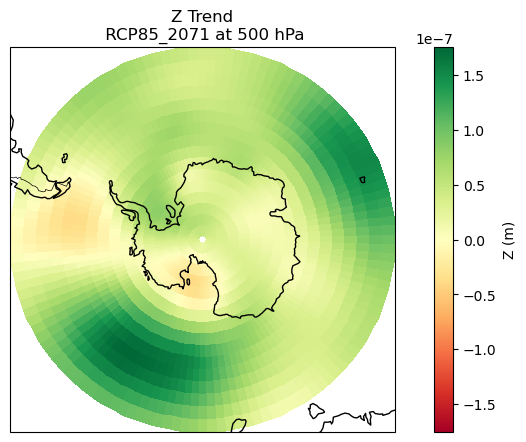

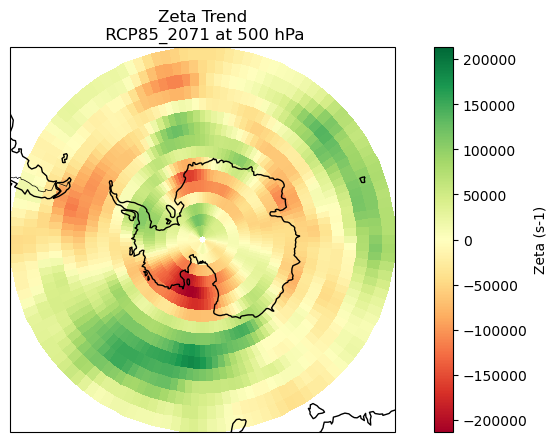

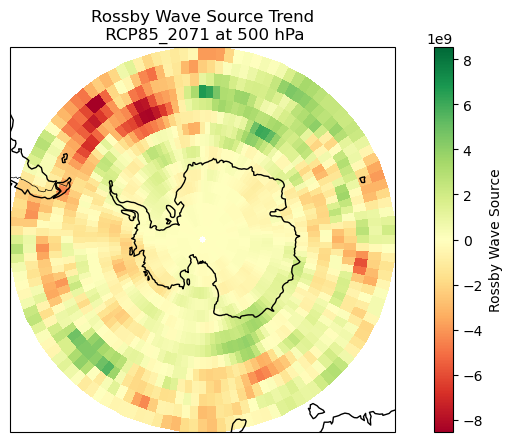

In [61]:
# Plot Spatial Trends over Time Period #

z_trend.name = 'Z (m)'
plot_field(z_trend, 
           title='Z Trend\n {}'.format(RCP_Text), 
           time_idx=-1, 
           level_value=50000, 
           save_file=path.join(SavePath,'z_trend_{}.png'.format(RCP_Text)), 
           cmap='RdYlGn',
           prj='SouthPolarStereo'
           )

zeta_trend.name = 'Zeta (s-1)'
plot_field(zeta_trend, 
           title='Zeta Trend\n {}'.format(RCP_Text), 
           time_idx=-1,
           level_value=50000,
           save_file=path.join(SavePath,'zeta_trend_{}.png'.format(RCP_Text)),
           cmap='RdYlGn',
           prj='SouthPolarStereo'
           )

rws_trend.name = 'Rossby Wave Source'
plot_field(rws_trend, 
           title='Rossby Wave Source Trend\n {}'.format(RCP_Text), 
           time_idx=-1, 
           level_value=50000,
           save_file=path.join(SavePath,'rws_trend_{}.png'.format(RCP_Text)),
           cmap='RdYlGn',
           prj='SouthPolarStereo'
           )


/Users/ryaneagan/Library/CloudStorage/GoogleDrive-reagan@udel.edu/My Drive/Spring 2025/Met Analysis GEOG654/GradProject/Met2GradProject/plot_tools.py:423: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.95])
/Users/ryaneagan/Library/CloudStorage/GoogleDrive-reagan@udel.edu/My Drive/Spring 2025/Met Analysis GEOG654/GradProject/Met2GradProject/plot_tools.py:425: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Adjust for colorbar space
/Users/ryaneagan/Library/CloudStorage/GoogleDrive-reagan@udel.edu/My Drive/Spring 2025/Met Analysis GEOG654/GradProject/Met2GradProject/plot_tools.py:423: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.95])
/Users/ryaneagan/Library/CloudStorage/Goo

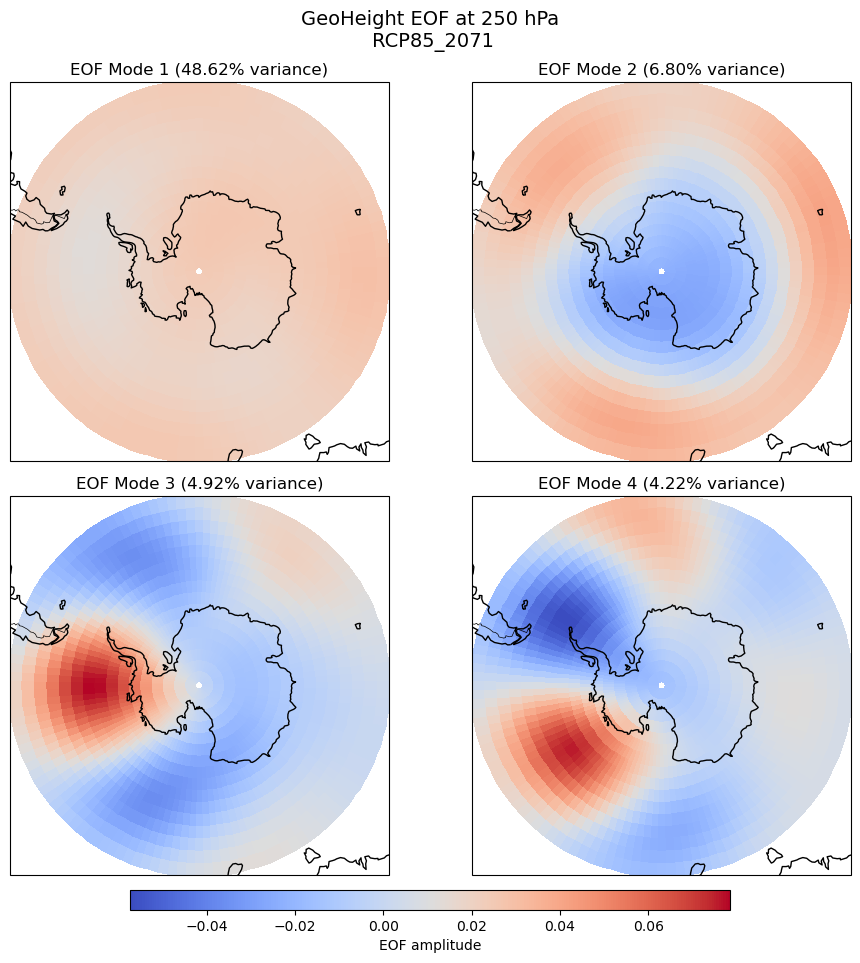

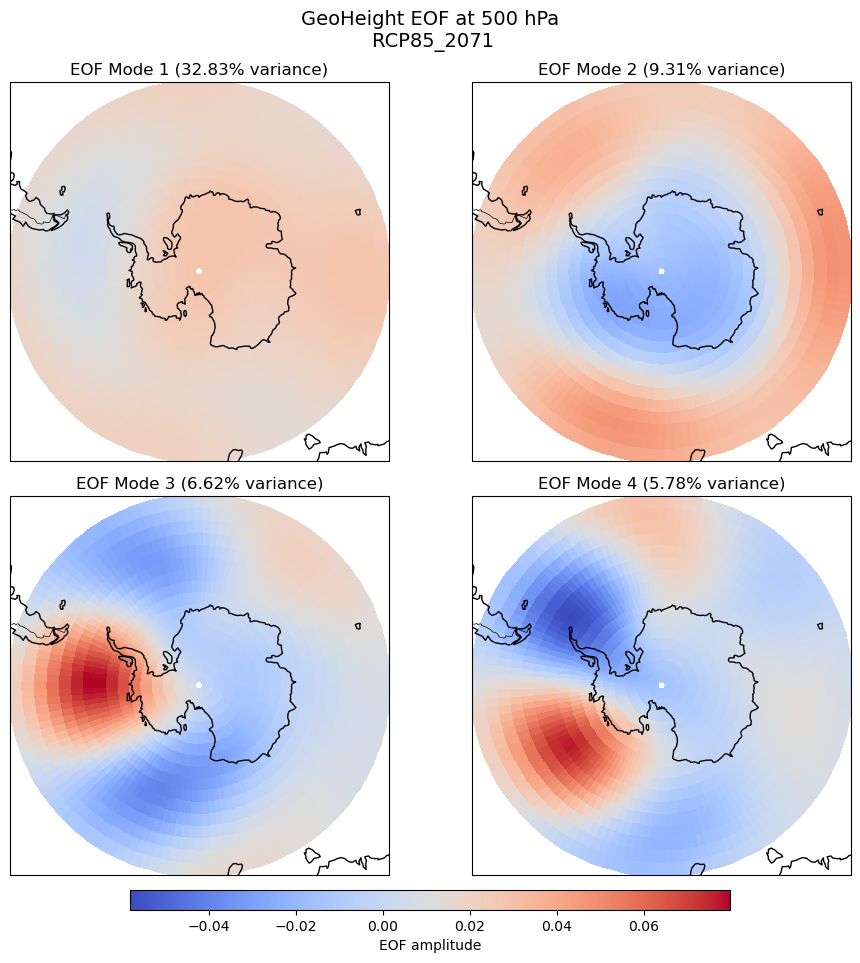

In [62]:
# Geopotential EOFs Plot#

plot_eofs_panel(z_eofs250, 
                z_pca250, 
                fig_title='GeoHeight EOF at 250 hPa\n {}'.format(RCP_Text), 
                save_file=path.join(SavePath,'z_eofs250_{}.png'.format(RCP_Text)),
                cmap='coolwarm',
                prj='SouthPolarStereo'
                )

plot_eofs_panel(z_eofs500, 
                z_pca500, 
                fig_title='GeoHeight EOF at 500 hPa\n {}'.format(RCP_Text),
                save_file=path.join(SavePath,'z_eofs500_{}.png'.format(RCP_Text)),
                cmap='coolwarm', 
                prj='SouthPolarStereo'
                )

/Users/ryaneagan/Library/CloudStorage/GoogleDrive-reagan@udel.edu/My Drive/Spring 2025/Met Analysis GEOG654/GradProject/Met2GradProject/plot_tools.py:423: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.95])
/Users/ryaneagan/Library/CloudStorage/GoogleDrive-reagan@udel.edu/My Drive/Spring 2025/Met Analysis GEOG654/GradProject/Met2GradProject/plot_tools.py:425: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Adjust for colorbar space
/Users/ryaneagan/Library/CloudStorage/GoogleDrive-reagan@udel.edu/My Drive/Spring 2025/Met Analysis GEOG654/GradProject/Met2GradProject/plot_tools.py:423: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.95])
/Users/ryaneagan/Library/CloudStorage/Goo

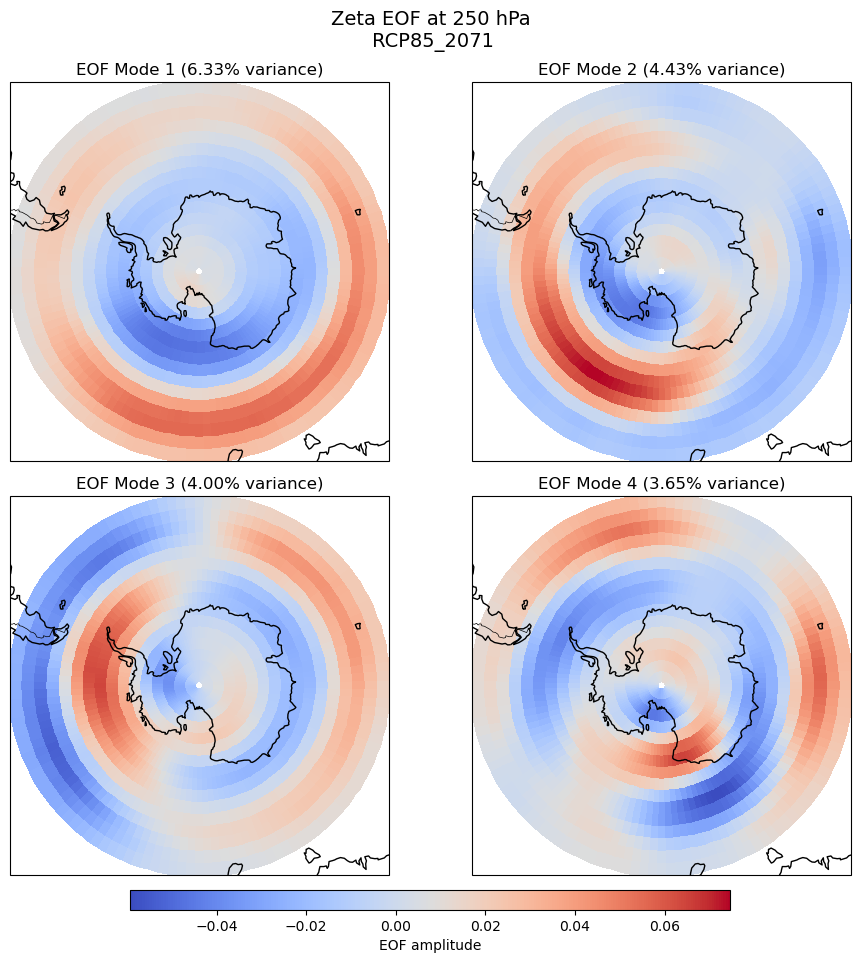

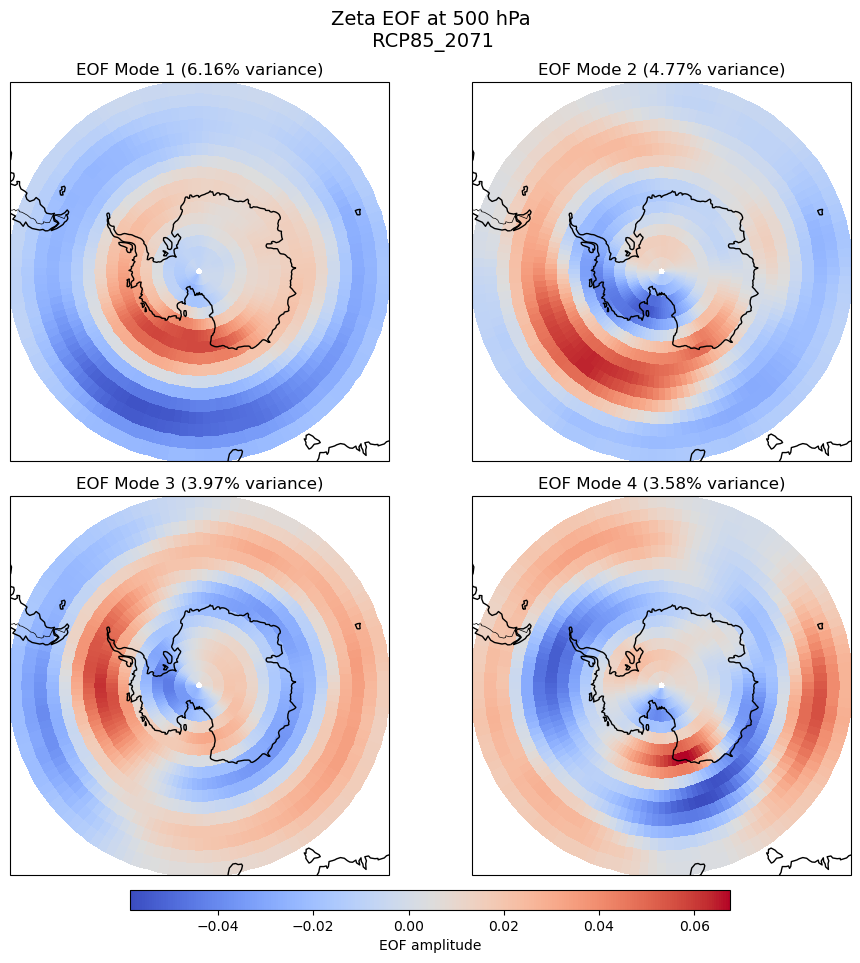

In [63]:
# Zeta EOFs Plot#

plot_eofs_panel(zeta_eofs250, 
                zeta_pca250,
                fig_title='Zeta EOF at 250 hPa\n {}'.format(RCP_Text),
                save_file=path.join(SavePath,'zeta_eofs250_{}.png'.format(RCP_Text)), cmap='coolwarm',
                prj='SouthPolarStereo'
                )

plot_eofs_panel(zeta_eofs500,
                zeta_pca500,
                fig_title='Zeta EOF at 500 hPa\n {}'.format(RCP_Text),
                save_file=path.join(SavePath,'zeta_eofs500_{}.png'.format(RCP_Text)),cmap='coolwarm', 
                prj='SouthPolarStereo'
                )

/Users/ryaneagan/Library/CloudStorage/GoogleDrive-reagan@udel.edu/My Drive/Spring 2025/Met Analysis GEOG654/GradProject/Met2GradProject/plot_tools.py:423: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.95])
/Users/ryaneagan/Library/CloudStorage/GoogleDrive-reagan@udel.edu/My Drive/Spring 2025/Met Analysis GEOG654/GradProject/Met2GradProject/plot_tools.py:425: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Adjust for colorbar space
/Users/ryaneagan/Library/CloudStorage/GoogleDrive-reagan@udel.edu/My Drive/Spring 2025/Met Analysis GEOG654/GradProject/Met2GradProject/plot_tools.py:423: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.95])
/Users/ryaneagan/Library/CloudStorage/Goo

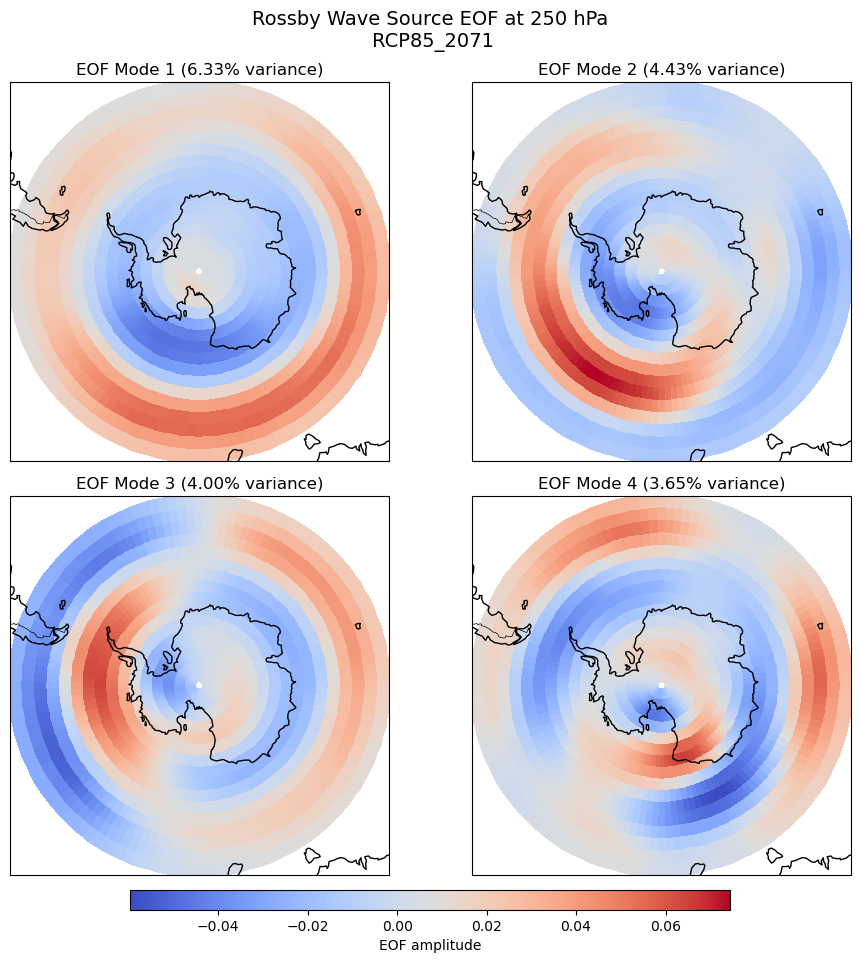

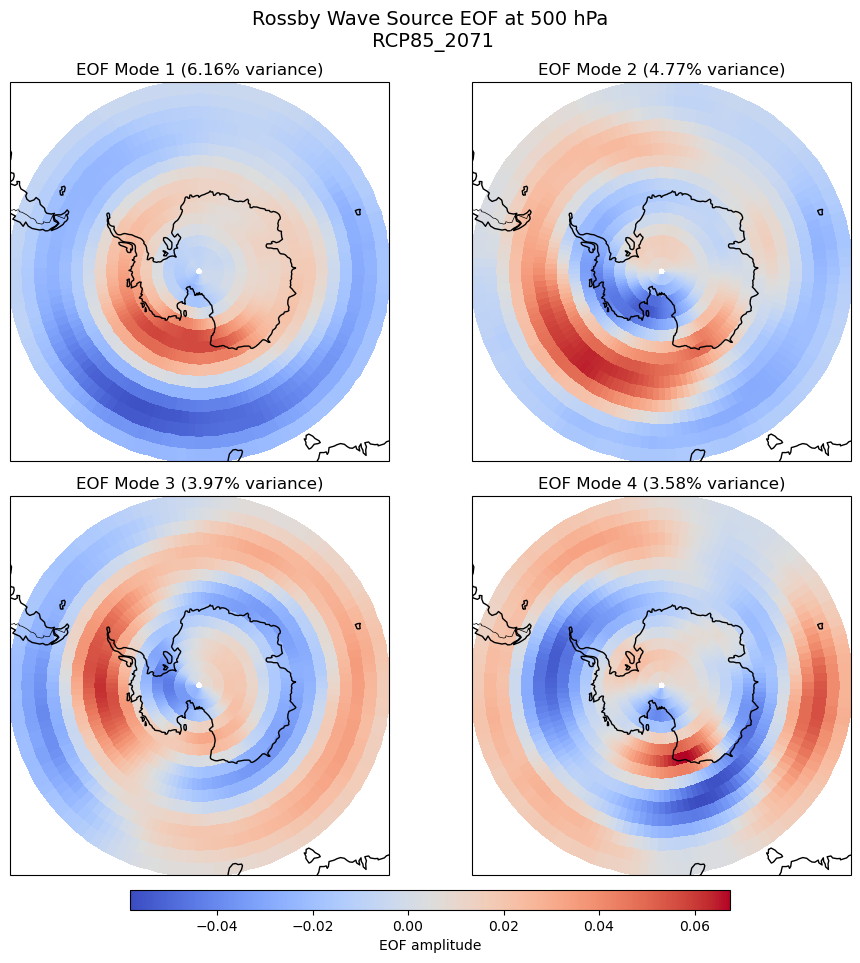

In [64]:
# RWS EOFs Plot#

plot_eofs_panel(rws_eofs250,
                rws_pca250,
                fig_title='Rossby Wave Source EOF at 250 hPa\n {}'.format(RCP_Text),
                save_file=path.join(SavePath,'rws_eofs250_{}.png'.format(RCP_Text)),cmap='coolwarm',
                prj='SouthPolarStereo'
                )

plot_eofs_panel(rws_eofs500,
                rws_pca500,
                fig_title='Rossby Wave Source EOF at 500 hPa\n {}'.format(RCP_Text),
                save_file=path.join(SavePath,'rws_eofs500_{}.png'.format(RCP_Text)), cmap='coolwarm',
                prj='SouthPolarStereo'
                )